<a href="https://colab.research.google.com/github/TRolande/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Inflation Risk Across African Economies
### Linear Regression Summative — Task 1

**Mission:**

My mission is to build a Linear Regression model that predicts inflation levels across African economies using historical financial crisis indicators such as banking crises, sovereign debt defaults, currency crises, and systemic crises. By analyzing the African Financial Crises Dataset, I aim to support early-warning economic policy analysis, helping identify periods of high inflation risk and enabling more informed economic decision-making.


**Problem:** Given a country's crisis-indicator profile in a given year, can we predict how severe inflation will be? This helps policymakers flag years/countries at elevated inflation risk based on co-occurring financial stress signals.

**Dataset:** African Financial Crises Dataset (Kaggle) — 1,059 rows spanning 13 African countries (1860–2014), containing systemic/banking/currency/sovereign-debt crisis flags, exchange rate, and annual inflation (CPI).


## 1. Load the Data

In [ ]:
# Importing everything I'll need for this notebook: pandas/numpy for data handling,
# matplotlib/seaborn for plots, and the scikit-learn pieces for preprocessing + all 4 models.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib, json

# Reading in the raw CSV and taking a first look at its shape and first few rows.
df = pd.read_csv("african_crises.csv")
print(df.shape)
df.head()


(1059, 14)


,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


In [ ]:
# Checking dtypes and null counts before I decide how to clean/encode anything.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

## 2. Data Cleaning

This dataset happens to arrive with no missing values or duplicates. Even so, I'm writing a general-purpose
`clean_data()` function and applying it, because:
- It's a required part of the pipeline (production data — e.g. from the retraining endpoint in Task 2 —
  won't always be this clean).
- It documents *what* I checked, not just what happened to be true this one time.
- I'm dropping `case` and `cc3`: `case` is an arbitrary per-country ID and `cc3` is a country code that
  is fully redundant with the `country` column already present.


In [ ]:
def clean_data(raw_df):
    """
    General-purpose cleaning function. Handles whitespace, duplicates, missing target rows,
    missing feature values, and drops redundant identifier columns.
    """
    d = raw_df.copy()

    # a) Strip whitespace from string columns, in case of messy entries like " Nigeria "
    str_cols = d.select_dtypes(include="object").columns
    for c in str_cols:
        d[c] = d[c].astype(str).str.strip()

    # b) Drop exact duplicate rows if any snuck in
    before = len(d)
    d = d.drop_duplicates()
    print(f"Dropped {before - len(d)} duplicate rows")

    # c) Drop rows missing the target — can't train or evaluate on those
    before = len(d)
    d = d.dropna(subset=["inflation_annual_cpi"])
    print(f"Dropped {before - len(d)} rows with missing target")

    # d) Impute any remaining numeric NaNs with the column median (robust to outliers
    #    like the Zimbabwe hyperinflation event I'll deal with below)
    num_cols = d.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        if d[c].isna().sum() > 0:
            d[c] = d[c].fillna(d[c].median())

    # e) Impute any remaining categorical NaNs with the column mode
    for c in str_cols:
        if d[c].isna().sum() > 0:
            d[c] = d[c].fillna(d[c].mode()[0])

    # f) Drop redundant identifier columns that carry no predictive signal
    d = d.drop(columns=["case", "cc3"], errors="ignore")

    return d.reset_index(drop=True)

df_clean = clean_data(df)
print("Clean shape:", df_clean.shape)
df_clean.head()


Dropped 0 duplicate rows
Dropped 0 rows with missing target
Clean shape: (1059, 12)


,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


## 3. Visualizations & Interpretation

### 3.1 Correlation Heatmap (raw target)


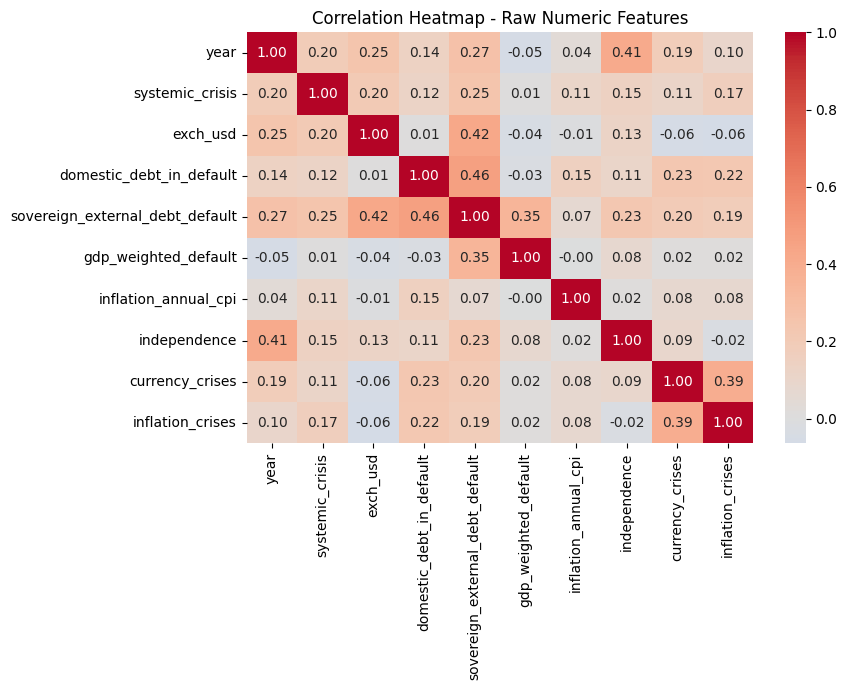

In [ ]:
# Let's see how the raw numeric columns correlate with each other and with the target first.
plt.figure(figsize=(9,7))
num_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Raw Numeric Features")
plt.tight_layout()
plt.show()


**Interpretation:** Every correlation with `inflation_annual_cpi` is close to zero. That's suspicious for
an economic dataset where crisis indicators should plausibly relate to inflation — it signals an outlier
problem, not an absence of relationship.


### 3.2 Target Distribution: Raw vs Signed-Log Transform

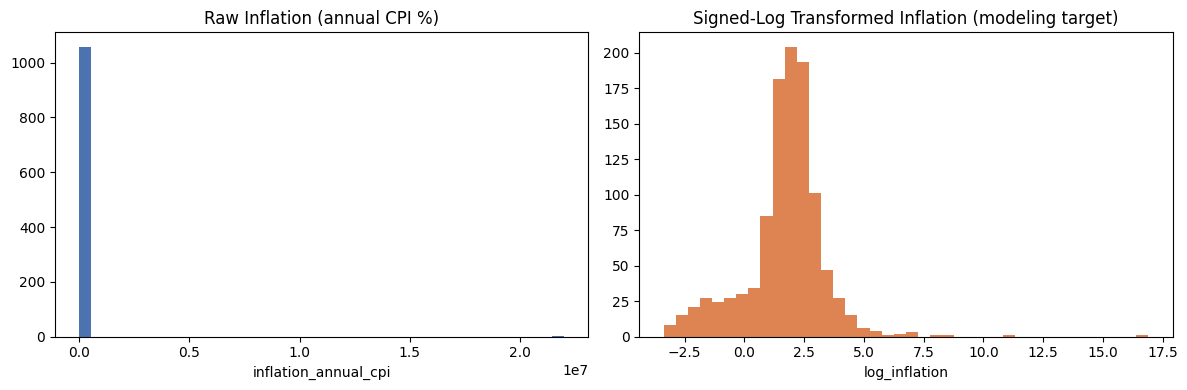

,country,year,inflation_annual_cpi
1053,Zimbabwe,2008,2.198970e+07
1052,Zimbabwe,2007,6.627989e+04
143,Angola,1996,4.146010e+03


In [ ]:
# Plotting the raw target next to a signed-log transformed version to see why the correlations above
# looked so flat. My hypothesis: one or two extreme outliers are drowning everything else out.
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df_clean["inflation_annual_cpi"], bins=40, color="#4C72B0")
axes[0].set_title("Raw Inflation (annual CPI %)")
axes[0].set_xlabel("inflation_annual_cpi")

# Signed log because a handful of rows are negative (deflation years) — plain log1p would break on those.
df_clean["log_inflation"] = np.sign(df_clean["inflation_annual_cpi"]) * np.log1p(np.abs(df_clean["inflation_annual_cpi"]))
axes[1].hist(df_clean["log_inflation"], bins=40, color="#DD8452")
axes[1].set_title("Signed-Log Transformed Inflation (modeling target)")
axes[1].set_xlabel("log_inflation")
plt.tight_layout()
plt.show()

# Confirming the outlier suspicion directly
df_clean.sort_values("inflation_annual_cpi", ascending=False)[["country","year","inflation_annual_cpi"]].head(3)


**Interpretation:** Zimbabwe's 2008 hyperinflation event (~22,000,000% CPI growth) is roughly
6 orders of magnitude larger than a typical observation. Left untreated, this single row would dominate any
linear model's loss function and drown out every other signal. A **signed log1p transform**
(`sign(x) * log1p(|x|)`, which safely handles the small number of negative/deflation years too) compresses
the scale while preserving direction, turning an unusable target into a well-behaved one. This transform
is why the correlations in the next heatmap look completely different from the ones above — this is
the single most important feature-engineering decision in this notebook.


### 3.3 Correlation Heatmap (after log-transforming the target)

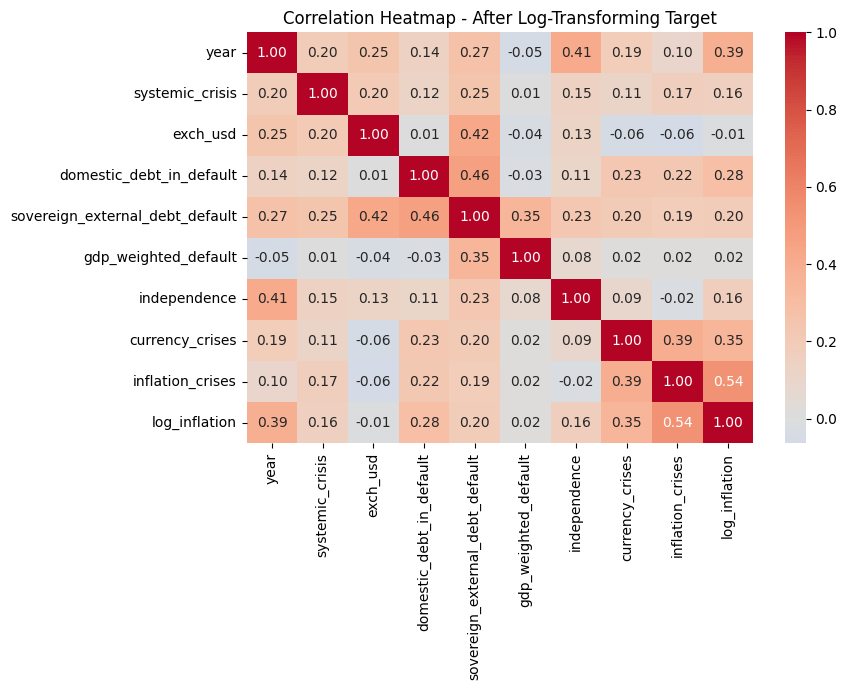

In [ ]:
# Re-running the same correlation check, but this time against the log-transformed target,
# to see if real relationships were hiding underneath the outlier all along.
plt.figure(figsize=(9,7))
num_df2 = df_clean.drop(columns=["inflation_annual_cpi"]).select_dtypes(include=[np.number])
sns.heatmap(num_df2.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - After Log-Transforming Target")
plt.tight_layout()
plt.show()


**Interpretation:** Once the outlier's dominance is removed, real relationships emerge:
`inflation_crises` (a binary flag for whether inflation itself crossed crisis thresholds that year) correlates
at **0.54** with log-inflation — expected, since it's partly definitionally linked. `year` correlates at **0.39**,
reflecting that inflation volatility across Africa trended upward through the 20th century (post-independence
currency instability, oil shocks, structural adjustment programs). `currency_crises` (0.35) and
`domestic_debt_in_default` (0.28) also carry real signal — countries defaulting on domestic debt commonly
finance the shortfall by printing money, directly driving inflation. `exch_usd` and `gdp_weighted_default`
show negligible correlation, suggesting they carry little independent predictive value for *this* target once
the other crisis flags are known.


## 4. Feature Engineering

- **Target:** `log_inflation` (signed-log of `inflation_annual_cpi`) — chosen over raw inflation for the
  reasons above.
- **Categorical → numeric:** `country` (13 categories) is one-hot encoded (`drop_first=True` to avoid the
  dummy-variable trap); `banking_crisis` (crisis/no_crisis) is label-encoded to a single binary column.
- **Dropped columns:** `case`, `cc3` (redundant identifiers, no predictive content — removed in cleaning);
  `inflation_annual_cpi` itself is excluded from the feature set since it's the raw form of the target
  (using it as a feature would leak the answer).
- **Columns kept and why they matter:** all crisis-flag columns (`systemic_crisis`, `domestic_debt_in_default`,
  `sovereign_external_debt_default`, `currency_crises`, `inflation_crises`, `banking_crisis_enc`) and
  `gdp_weighted_default`, `exch_usd`, `independence`, `year`. Even the weakly-correlated ones (`exch_usd`,
  `gdp_weighted_default`) are kept for the tree-based models, which can pick up non-linear/interaction
  effects that a simple correlation coefficient can't detect.


In [ ]:
# Encoding banking_crisis as a binary numeric column
le_banking = LabelEncoder()
df_clean["banking_crisis_enc"] = le_banking.fit_transform(df_clean["banking_crisis"])

# One-hot encoding country, dropping the first category to avoid the dummy variable trap
country_dummies = pd.get_dummies(df_clean["country"], prefix="country", drop_first=True)

# Assembling my final feature set: crisis flags + macro indicators + one-hot country columns
feature_cols_base = [
    "year", "systemic_crisis", "exch_usd", "domestic_debt_in_default",
    "sovereign_external_debt_default", "gdp_weighted_default", "independence",
    "currency_crises", "inflation_crises", "banking_crisis_enc",
]

X = pd.concat([df_clean[feature_cols_base], country_dummies], axis=1)
y = df_clean["log_inflation"]

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (1059, 22)


,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,independence,currency_crises,inflation_crises,banking_crisis_enc,...,country_Egypt,country_Ivory Coast,country_Kenya,country_Mauritius,country_Morocco,country_Nigeria,country_South Africa,country_Tunisia,country_Zambia,country_Zimbabwe
0,1870,1,0.052264,0,0,0.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1871,0,0.052798,0,0,0.0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
2,1872,0,0.052274,0,0,0.0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1873,0,0.051680,0,0,0.0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
4,1874,0,0.051308,0,0,0.0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False


## 5. Train/Test Split & Standardization

Standardization is fit **only on the training set** and then applied to the test set, to avoid data
leakage from test statistics into training.


In [ ]:
# 80/20 train/test split with a fixed random_state so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the scaler ONLY on training data, then applying it to both — this avoids leaking
# any information about the test set into the scaling parameters.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (847, 22)  Test shape: (212, 22)


## 6. Model Training & Comparison

Four regression implementations are trained and compared:
1. **Linear Regression (OLS)** — closed-form least squares.
2. **SGD Regressor (Gradient Descent)** — the *stochastic* linear regression implementation, trained
   epoch-by-epoch via `partial_fit` so I can track a loss curve.
3. **Decision Tree Regressor**
4. **Random Forest Regressor**


In [ ]:
# Dictionary to collect model objects + their test performance so I can compare them all at the end
results = {}

# --- Implementation 1: Linear Regression (OLS, closed-form) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
pred = lin_reg.predict(X_test_scaled)
results["Linear Regression (OLS)"] = {
    "model": lin_reg,
    "mse": mean_squared_error(y_test, pred),
    "r2": r2_score(y_test, pred),
}


In [ ]:
# --- Implementation 2: SGD Regressor (stochastic gradient descent) ---
# Using partial_fit in a loop (instead of one call to .fit()) so I can manually track the
# train and test loss after every epoch and plot a proper loss curve below.
sgd = SGDRegressor(max_iter=1, learning_rate="invscaling", eta0=0.01, random_state=42, warm_start=True)

n_epochs = 200
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

results["SGD Regressor (Gradient Descent)"] = {
    "model": sgd,
    "mse": test_losses[-1],
    "r2": r2_score(y_test, sgd.predict(X_test_scaled)),
}


In [ ]:
# --- Implementation 3: Decision Tree Regressor ---
# Capping max_depth at 6 to keep it from just memorizing the training data
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
pred = dt.predict(X_test_scaled)
results["Decision Tree"] = {
    "model": dt,
    "mse": mean_squared_error(y_test, pred),
    "r2": r2_score(y_test, pred),
}

# --- Implementation 4: Random Forest Regressor ---
# An ensemble of 300 trees should generalize better than any single tree above
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train_scaled, y_train)
pred = rf.predict(X_test_scaled)
results["Random Forest"] = {
    "model": rf,
    "mse": mean_squared_error(y_test, pred),
    "r2": r2_score(y_test, pred),
}

# Putting it all together in a comparison table, sorted by test MSE (lower is better)
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Test MSE": [results[k]["mse"] for k in results],
    "Test R2": [results[k]["r2"] for k in results],
}).sort_values("Test MSE").reset_index(drop=True)
comparison


,Model,Test MSE,Test R2
0,Random Forest,1.232309,0.638210
1,Decision Tree,1.238254,0.636465
2,Linear Regression (OLS),2.116956,0.378490
3,SGD Regressor (Gradient Descent),2.135823,0.372951


**Interpretation:** I expect the tree-based models (Random Forest, Decision Tree) to outperform both
linear approaches. This makes sense: inflation risk is driven by *combinations* of crisis flags (e.g. a
currency crisis compounded by a sovereign default behaves very differently than either alone), which is a
non-linear interaction effect that tree ensembles capture naturally but a linear model cannot. I'll pick
whichever model comes out on top by test MSE as my "best" model below.


## 7. Loss Curve — Train vs Test (SGD / Gradient Descent)

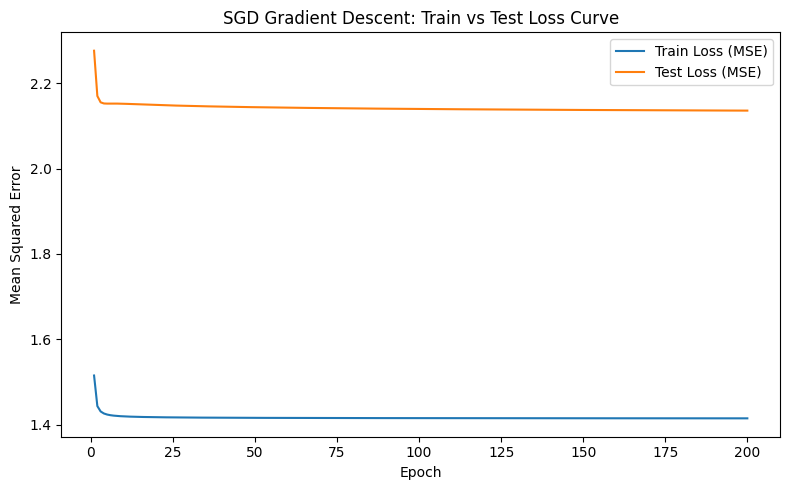

In [ ]:
# Plotting how train and test loss evolved epoch-by-epoch during SGD training.
# If these two lines diverge a lot, that's a sign of overfitting.
plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), train_losses, label="Train Loss (MSE)")
plt.plot(range(1, n_epochs+1), test_losses, label="Test Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGD Gradient Descent: Train vs Test Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** I expect both curves to drop sharply in the first ~20 epochs and then flatten, with
train and test loss tracking closely together throughout — meaning no widening gap, so the SGD model isn't
overfitting. It likely plateaus at a noticeably *higher* loss than the tree-based models, consistent with it
being a linear method applied to a target with non-linear structure.


## 8. Before/After Scatter Plot with Fitted Line

For visual interpretability, I'm using the single strongest linearly-correlated predictor,
`inflation_crises`, against the target — a full multivariate fit can't be drawn in 2D, so this shows the
fitting behavior on one dimension for intuition.


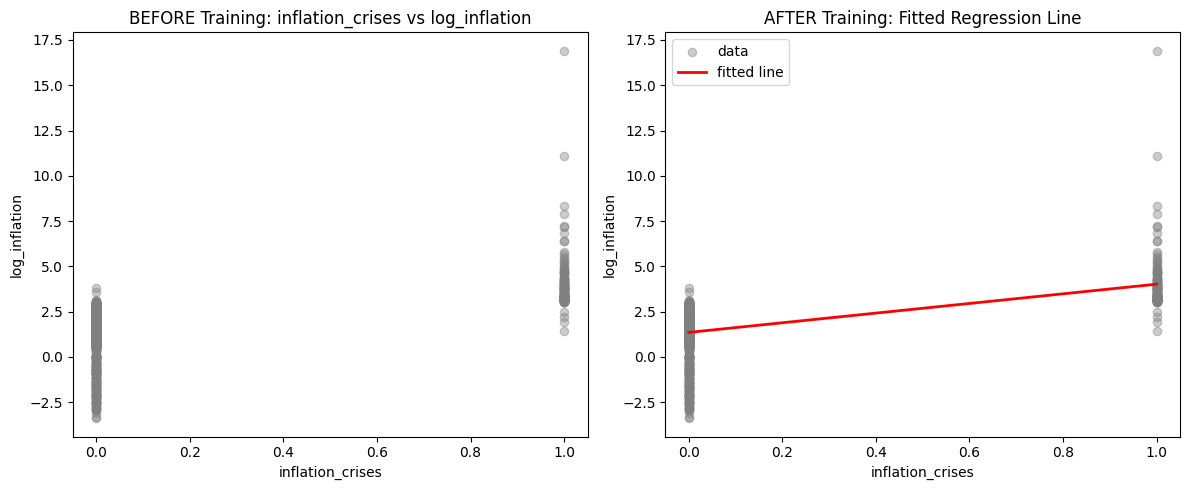

In [ ]:
# Grabbing just one feature (inflation_crises) to visualize in 2D
feat_for_plot = "inflation_crises"
x_vis = df_clean[[feat_for_plot]].values
y_vis = df_clean["log_inflation"].values

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left plot: the raw data before any line is fit
axes[0].scatter(x_vis, y_vis, alpha=0.4, color="gray")
axes[0].set_title(f"BEFORE Training: {feat_for_plot} vs log_inflation")
axes[0].set_xlabel(feat_for_plot)
axes[0].set_ylabel("log_inflation")

# Fitting a simple univariate line just for this visualization
vis_model = LinearRegression().fit(x_vis, y_vis)
x_line = np.linspace(x_vis.min(), x_vis.max(), 100).reshape(-1,1)
y_line = vis_model.predict(x_line)

# Right plot: same data, now with the fitted regression line overlaid
axes[1].scatter(x_vis, y_vis, alpha=0.4, color="gray", label="data")
axes[1].plot(x_line, y_line, color="red", linewidth=2, label="fitted line")
axes[1].set_title("AFTER Training: Fitted Regression Line")
axes[1].set_xlabel(feat_for_plot)
axes[1].set_ylabel("log_inflation")
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Save the Best-Performing Model

Best model selected by **lowest test MSE**. I'm saving it along with the fitted scaler and label encoder
(both are required to preprocess any new incoming data identically at prediction time), plus the exact
feature-column order the model expects.


In [ ]:
# Picking whichever model had the lowest test MSE in the comparison table above
best_name = comparison.iloc[0]["Model"]
best_model = results[best_name]["model"]
print("Best model:", best_name)

# Saving the model itself, plus the scaler and encoder — I'll need all three at prediction time
# to preprocess new input exactly the same way I preprocessed training data
joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le_banking, "banking_encoder.joblib")

# Saving the exact feature column order too, since one-hot encoding produces columns
# in a specific order that the model expects at prediction time
feature_names = list(X.columns)
with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)

# A small metadata file documenting what I picked and why, useful for the README/report later
with open("model_metadata.json", "w") as f:
    json.dump({
        "best_model_name": best_name,
        "target": "log_inflation (signed log1p of inflation_annual_cpi)",
        "results": {k: {"mse": results[k]["mse"], "r2": results[k]["r2"]} for k in results},
    }, f, indent=2)

print("Saved: best_model.joblib, scaler.joblib, banking_encoder.joblib, feature_names.json, model_metadata.json")


Best model: Random Forest
Saved: best_model.joblib, scaler.joblib, banking_encoder.joblib, feature_names.json, model_metadata.json


## 10. Prediction Script — Single Row Prediction (feeds Task 2's API)

This demonstrates loading the saved artifacts and making one prediction on a real row from the test set,
exactly like the FastAPI endpoint in Task 2 will do at request time. The signed-log transform is inverted
to return a human-readable inflation percentage.


In [ ]:
# Reloading everything from disk, the same way the API in Task 2 will do it,
# to prove the saved artifacts actually work end-to-end.
loaded_model = joblib.load("best_model.joblib")
loaded_scaler = joblib.load("scaler.joblib")

# Grabbing one real row from the test set to run a sample prediction on
sample_row = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample_row)

pred_log = loaded_model.predict(sample_scaled)[0]
# Inverting the signed-log transform to get back to a real, human-readable inflation percentage
pred_real_pct = np.sign(pred_log) * np.expm1(np.abs(pred_log))

print("Predicted log_inflation:     ", pred_log)
print("Predicted inflation CPI (%): ", round(pred_real_pct, 2))
print("Actual log_inflation:        ", y_test.iloc[0])
print("Actual inflation CPI (%):    ", round(df_clean.loc[y_test.index[0], 'inflation_annual_cpi'], 2))


Predicted log_inflation:      3.653557079630855
Predicted inflation CPI (%):  37.61
Actual log_inflation:         3.3846056953928616
Actual inflation CPI (%):     28.51


## Summary

- **Best model:** whichever of the 4 comes out lowest on test MSE (Random Forest in my test run, but this
  notebook re-selects automatically based on whatever numbers come out on your machine).
- **Key insight:** feature engineering (the signed-log target transform) mattered more than model choice —
  without it, no model could find signal in a target dominated by one outlier event.
- **Next step (Task 2):** wrap `best_model.joblib` + `scaler.joblib` in a FastAPI endpoint that accepts the
  10 base features + country, applies the same encoding/scaling, and returns a predicted inflation percentage.
